# Five fresh sample comparisons of the selected SVM configurations

This notebook checks whether the earlier improvement persists across five fresh,
disjoint 2,000-row samples from the same original CSV. It does not repeat the
parameter search or select the best-looking sample.

## The two fixed models

- **Original selected:** unscaled RBF SVM, `C=100`, `gamma='scale'`.
- **Enhanced selected:** StandardScaler plus RBF SVM, `C=1`, `gamma=0.1`.

`C` controls the training-error penalty; `gamma` controls the reach of the RBF
kernel. These settings were selected in the previous notebook and stay fixed here.
Each sample has 1,400 training rows and 600 development-evaluation rows with the
earlier class counts. Both models share the same rows and 50 shuffled grouped CV
folds within each sample. StandardScaler learns only from the corresponding training rows.

## Run in Jupyter or Anaconda

1. Use your Python 3.11 environment and the packages in `requirements.txt`.
2. Set `DATASET_PATH`, `EVIDENCE_ZIP` and `HISTORY_ROOT`. See [input requirements](../docs/INPUTS.md) for the required private history files.
3. Start a fresh kernel. Run the sampling and boundary checks before training.
4. Keep seeds 42–46 and both model settings unchanged. Do not bypass failed checks or choose replacement samples based on scores.
5. Complete every sample, then save the notebook and package its evidence.

The training stage performs 500 CV fits, 10 full-training fits and, with the
existing control enabled, five shuffled-label fits. Those controls check behavior
when training labels are randomized; they do not select model parameters.

## Reading the code and results

Descriptive index names identify training, evaluation and CV fold rows.
`find_group` and `merge_groups` connect rows sharing a Flow ID or an exact feature
vector so related records stay on the same side of a checked boundary.
`evidence_dir` holds the predictions, metrics and audit files.

**Recorded output** cells preserve the earlier user runs. This reconstructed
publication edition has not been trained or rerun. The refactor preserves the
sampling, fitting and evidence checks. Report all five samples, their mean and
spread, and the paired changes rather than a single best score.

Historical and reserved Flow IDs are excluded from modelling. The old reserve
had prior historical exposure and is not scored here. Group checks do not establish
whole-host, campaign or near-duplicate independence. The 77-feature schema was
inherited from population-wide column retention. Five samples from one day provide
development-validation evidence, not an untouched final test or a deployment guarantee.


In [ ]:
# Imports, paths, fixed configurations, and evidence helpers.

from pathlib import Path
from datetime import datetime, timezone
from time import perf_counter
import hashlib
import io
import json
import platform
import uuid
import warnings
import zipfile
import gc
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import scipy
import joblib
from IPython.display import display
from sklearn.base import clone
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    make_scorer
)

DATASET_PATH = Path("../data/data_4.csv")
EVIDENCE_ZIP = Path("../private_inputs/20261004T102021Z_45a6d3fc_evidence.zip")
HISTORY_ROOT = Path("../private_inputs/history")
NOTEBOOK_PATH = Path("SVM_Experiment_4_Repeated_Sample_Validation.ipynb")
OUTPUT_ROOT = Path("svm_repeated_sample_evidence")
SEEDS = [42, 43, 44, 45, 46]
COHORT_SEED = 20261004
N_FOLDS = 50
N_JOBS = 2
CHUNK_ROWS = 100000
RUN_SHUFFLED_LABEL_CONTROL = True
EXPECTED_DATASET_SHA256 = "7287a4d7740a1dddbf330ceb2beb6a4889d33ba63674558a68b5eb50d16711df"
EXPECTED_INPUT_SHA256 = "cdc4661d5114c0bf2bd4f253b1da24836a8c0918b2eee360fcf0f22f7a353faf"
LABEL_MAP = {"Benign": 0, "DDoS attacks-LOIC-HTTP": 1}
SETTINGS = {
    "original_selected": {"kernel": "rbf", "C": 100, "gamma": "scale"},
    "enhanced_selected": {"kernel": "rbf", "C": 1, "gamma": 0.1}
}
for path in [DATASET_PATH, EVIDENCE_ZIP]:
    assert path.is_file(), f"Correct this path before continuing: {path}"
assert HISTORY_ROOT.is_dir(), "Set HISTORY_ROOT to the folder containing option-b and option-c."
run_id = datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]
evidence_dir = OUTPUT_ROOT / run_id
evidence_dir.mkdir(parents=True, exist_ok=False)


# Save the current evidence record as readable JSON.
def save_json(name, value):
    (evidence_dir / name).write_text(json.dumps(value, indent=2, allow_nan=False), encoding="utf-8")


# Read a file in small blocks and calculate its identity checksum.
def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open("rb") as stream:
        for block in iter(lambda: stream.read(8 * 1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest()


# Keep the source convention: replace spaces in column names.
def normalise(name):
    return str(name).replace(" ", "_")


# Identify exact feature rows; treat positive and negative zero alike.
def feature_hash(row):
    canonical = np.array(row, dtype="<f8", copy=True)
    canonical[canonical == 0] = 0.0
    return hashlib.sha256(canonical.tobytes()).hexdigest()

save_json("environment.json", {
    "python": platform.python_version(),
    "numpy": np.__version__,
    "pandas": pd.__version__,
    "sklearn": sklearn.__version__,
    "scipy": scipy.__version__,
    "joblib": joblib.__version__
})
print("Python", platform.python_version(), "| sklearn", sklearn.__version__)
print("Output:", evidence_dir.resolve())


**Recorded output from the supplied run — not rerun here**

    Python 3.11.17 | sklearn 1.9.1
    Output: [local folder]/20261004T113920Z_f73df1ba
    



## 1. Verify source evidence and freeze the feature list and class counts
Read saved arrays with allow_pickle=False; do not load supplied model files. A missing source checksum manifest is recorded as a packaging limitation. The known frozen-input digest remains mandatory. The full CSV is hashed before sampling to confirm dataset identity.




In [ ]:
# Verify earlier evidence and retain its feature names and class quotas.

with zipfile.ZipFile(EVIDENCE_ZIP) as archive:
    names = [name for name in archive.namelist() if name.endswith("/frozen_inputs.npz")]
    assert len(names) == 1
    prefix = names[0].rsplit("/", 1)[0] + "/"
    source_audit = json.loads(archive.read(prefix + "dataset_audit.json"))
    source_settings = json.loads(archive.read(prefix + "experiment_settings.json"))
    with np.load(io.BytesIO(archive.read(names[0])), allow_pickle=False) as data:
        frozen = {key: data[key].copy() for key in data.files}
    old_membership = pd.read_csv(io.BytesIO(archive.read(prefix + "split_membership.csv")))
    manifest_present = prefix + "manifest_sha256.json" in archive.namelist()
    manifest_count = 0
    if manifest_present:
        manifest = json.loads(archive.read(prefix + "manifest_sha256.json"))
        for name, expected in manifest.items():
            assert name != "manifest_sha256.json", "Manifest must not include itself."
            assert hashlib.sha256(archive.read(prefix + name)).hexdigest() == expected, name
        manifest_count = len(manifest)
    else:
        warnings.warn("Earlier evidence manifest is absent; record this packaging limitation.")

input_hash = hashlib.sha256(
    frozen["X_train"].tobytes() + frozen["X_eval"].tobytes() +
    frozen["y_train"].tobytes() + frozen["y_eval"].tobytes()
).hexdigest()
assert input_hash == EXPECTED_INPUT_SHA256 == source_settings["training_input_sha256"]
assert source_audit["dataset_sha256"] == EXPECTED_DATASET_SHA256
assert source_settings["tuning_executed"] is True
feature_names = source_audit["feature_names"]
assert len(feature_names) == 77 and len(set(feature_names)) == 77
assert "Label" not in feature_names and "Flow_ID" not in feature_names
train_quota = {label: int((frozen["y_train"] == label).sum()) for label in [0, 1]}
eval_quota = {label: int((frozen["y_eval"] == label).sum()) for label in [0, 1]}
assert train_quota == {0: 679, 1: 721} and eval_quota == {0: 324, 1: 276}
original_feature_hashes = set(feature_hash(row) for row in np.vstack([frozen["X_train"], frozen["X_eval"]]))
csv_initial_stat = DATASET_PATH.stat()
print("Checking full CSV identity; this may take a little time.")
assert sha256_file(DATASET_PATH) == EXPECTED_DATASET_SHA256, "Different CSV: review protocol before continuing."
save_json("source_provenance.json", {
    "dataset_path": str(DATASET_PATH.resolve()),
    "dataset_sha256": EXPECTED_DATASET_SHA256,
    "evidence_zip": str(EVIDENCE_ZIP.resolve()),
    "evidence_sha256": sha256_file(EVIDENCE_ZIP),
    "original_input_sha256": input_hash,
    "source_manifest_present": manifest_present,
    "source_manifest_verified_files": manifest_count,
    "feature_names": feature_names,
    "train_quota": train_quota,
    "evaluation_quota": eval_quota,
    "feature_origin_limitation": "Fixed earlier population-derived 77-column schema."
})
print("Frozen training counts:", train_quota, "| evaluation counts:", eval_quota)


**Recorded output from the supplied run — not rerun here**

    [local kernel file]:19: UserWarning: Earlier evidence manifest is absent; record this packaging limitation.
      warnings.warn("Earlier evidence manifest is absent; record this packaging limitation.")
    

    Checking full CSV identity; this may take a little time.
    Frozen training counts: {0: 679, 1: 721} | evaluation counts: {0: 324, 1: 276}
    



## 2. Protect tracked history and the existing reserve
Read historical **row IDs only** from earlier modelling manifests and the reserved manifest. Identify their Flow IDs during the metadata scan, then exclude every row in those groups. This protection concerns modelling use: no reserved model predictions, scores or aggregate results are calculated.

The history list is deliberately explicit. If other experiments used additional rows, add their row-ID CSVs to EXTRA_HISTORY_FILES before execution. Unknown history cannot be certified.




In [ ]:
# Exclude tracked historical rows and every protected Flow ID.

EXTRA_HISTORY_FILES = []  # Optional Paths; each CSV must have original_row_id or csv_row_id.
required_history = [
    HISTORY_ROOT / "option-b/selected_rows_metadata.csv",
    HISTORY_ROOT / "option-c/validation_metadata.csv",
    HISTORY_ROOT / "matched-source-comparison/matched_rows.csv"
]
training_history = sorted((HISTORY_ROOT / "option-c").glob("train_*_row_ids.csv"))
assert len(training_history) == 10, "Expected five 2,000-row and five 4,000-row training manifests."
reserve_path = HISTORY_ROOT / "option-c/reserved_test_row_ids.csv"
history_files = required_history + training_history + [reserve_path] + list(EXTRA_HISTORY_FILES)
history_ids = set(old_membership["csv_row_id"].astype(int))
reserve_ids = set()
history_records = []
for path in history_files:
    assert path.is_file(), f"Missing historical membership file: {path}"
    columns = pd.read_csv(path, nrows=0).columns
    key = "original_row_id" if "original_row_id" in columns else "csv_row_id"
    assert key in columns
    ids = pd.read_csv(path, usecols=[key])[key].to_numpy(dtype=np.int64)
    assert len(ids) == len(np.unique(ids))
    history_ids.update(map(int, ids))
    if path == reserve_path:
        reserve_ids.update(map(int, ids))
    history_records.append({"path": str(path.resolve()), "rows": len(ids), "sha256": sha256_file(path)})
assert len(reserve_ids) == 50001
history_ids_array = np.array(sorted(history_ids), dtype=np.int64)

header = list(pd.read_csv(DATASET_PATH, nrows=0).columns)
mapping = {normalise(name): name for name in header}
assert len(mapping) == len(header), "Ambiguous normalised header."
assert {"Flow_ID", "Dst_Port", "Label", *feature_names}.issubset(mapping)
meta_columns = [mapping[key] for key in ["Flow_ID", "Dst_Port", "Label"]]
meta_dtypes = {mapping["Flow_ID"]: "string", mapping["Label"]: "string", mapping["Dst_Port"]: np.float64}
parts, protected_flows, offset, matched_history = [], set(), 0, set()
for number, chunk in enumerate(
    pd.read_csv(DATASET_PATH, usecols=meta_columns, dtype=meta_dtypes, chunksize=CHUNK_ROWS),
    1
):
    chunk.columns = [normalise(name) for name in chunk.columns]
    ids = np.arange(offset, offset + len(chunk), dtype=np.int64)
    tracked = np.isin(ids, history_ids_array)
    if tracked.any():
        assert chunk.loc[tracked, "Flow_ID"].notna().all()
        protected_flows.update(chunk.loc[tracked, "Flow_ID"].astype(str))
        matched_history.update(map(int, ids[tracked]))
    # Reserve/history labels are discarded before label mapping or retention.
    keep = chunk["Dst_Port"].isin([80, 443]).to_numpy() & ~tracked
    candidate = chunk.loc[keep, ["Flow_ID", "Label"]].copy()
    assert candidate["Flow_ID"].notna().all()
    mapped_labels = candidate["Label"].map(LABEL_MAP)
    assert mapped_labels.notna().all(), "Unexpected label in eligible traffic."
    parts.append(pd.DataFrame({
        "csv_row_id": ids[keep],
        "Flow_ID": candidate["Flow_ID"].astype(str).to_numpy(),
        "label": mapped_labels.to_numpy(dtype=np.int8)
    }))
    offset += len(chunk)
    if number % 20 == 0:
        print(f"Metadata scan: {offset:,} rows.")
assert offset == source_audit["raw_rows"]
assert matched_history == history_ids, "Some protected IDs were not found in this CSV."
pool = pd.concat(parts, ignore_index=True)
pool = pool.loc[~pool["Flow_ID"].isin(protected_flows)].reset_index(drop=True)
del parts, chunk
gc.collect()
assert not set(pool["csv_row_id"]).intersection(history_ids)
assert not set(pool["Flow_ID"]).intersection(protected_flows)
pool["group"] = pd.factorize(pool["Flow_ID"], sort=True)[0]
history_audit = {
    "known_history_rows_including_reserve": len(history_ids),
    "protected_reserve_rows": len(reserve_ids),
    "protected_flow_ids": len(protected_flows),
    "eligible_rows_after_exclusions": len(pool),
    "eligible_flow_groups": int(pool["group"].nunique()),
    "history_files": history_records,
    "historical_membership_complete_for_listed_files": True,
    "unknown_external_history_certified": False,
    "reserve_scored": False,
    "old_reserve_prior_exposure": "Earlier audit found prior exposure; no claim of untouched final evidence."
}
save_json("history_exclusion_audit.json", history_audit)
print("Eligible rows:", len(pool), "| known protected Flow IDs:", len(protected_flows))


**Recorded output from the supplied run — not rerun here**

    Metadata scan: 2,000,000 rows.
    Metadata scan: 4,000,000 rows.
    Metadata scan: 6,000,000 rows.
    Metadata scan: 7,948,748 rows.
    Eligible rows: 2493461 | known protected Flow IDs: 59696
    



## 3. Choose five fresh samples before viewing model scores
A fixed random permutation assigns entire Flow IDs to five disjoint cohorts. Inside each cohort, a 70/30 group split supplies separate training and evaluation pools. Predefined class quotas then select 1,400/600 rows.

Sampling class proportions deliberately match the earlier balanced sample rather than the natural population. Therefore ordinary accuracy and predictive precision apply to this sampled task, not automatically to real deployment prevalence. Cohorts, sampling seeds and quotas cannot be changed after inspecting scores.




In [ ]:
# Choose all five samples using the unchanged random seeds.

unique_groups = np.arange(pool["group"].nunique())
cohort_rng = np.random.default_rng(COHORT_SEED)
cohort_assignment = np.empty(len(unique_groups), dtype=np.int8)
cohort_assignment[cohort_rng.permutation(unique_groups)] = np.arange(len(unique_groups)) % len(SEEDS)
pool["cohort"] = cohort_assignment[pool["group"].to_numpy()]
selected_meta_parts, sample_plan = [], {}
for cohort, seed in enumerate(SEEDS):
    candidate = pool.loc[pool["cohort"] == cohort].reset_index(drop=True)
    group_split = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=seed)
    train_indices, evaluation_indices = next(group_split.split(
        np.zeros((len(candidate), 1)),
        groups=candidate["group"].to_numpy()
    ))
    rng = np.random.default_rng(seed)
    seed_parts = []
    for role, positions, quota in [
        ("training", train_indices, train_quota),
        ("development_evaluation", evaluation_indices, eval_quota)
    ]:
        for label in [0, 1]:
            eligible = positions[candidate.iloc[positions]["label"].to_numpy() == label]
            assert len(eligible) >= quota[label], f"Seed {seed}, {role}, class {label}: insufficient rows."
            chosen = rng.choice(eligible, size=quota[label], replace=False)
            part = candidate.iloc[chosen].copy()
            part["seed"], part["role"] = seed, role
            seed_parts.append(part)
    sampled = pd.concat(seed_parts, ignore_index=True)
    sampled = sampled.iloc[rng.permutation(len(sampled))].reset_index(drop=True)
    assert len(sampled) == 2000
    selected_meta_parts.append(sampled)
sample_metadata = pd.concat(selected_meta_parts, ignore_index=True)
assert len(sample_metadata) == 10000 and sample_metadata["csv_row_id"].is_unique
assert sample_metadata.groupby("Flow_ID")["seed"].nunique().max() == 1
assert sample_metadata.groupby("Flow_ID")["role"].nunique().max() == 1
assert not set(sample_metadata["csv_row_id"]).intersection(history_ids)
assert not set(sample_metadata["Flow_ID"]).intersection(protected_flows)
sample_metadata.to_csv(evidence_dir / "sampling_membership_before_features.csv", index=False)
selected_row_ids = sample_metadata["csv_row_id"].to_numpy(dtype=np.int64)
del pool, candidate, selected_meta_parts, unique_groups
gc.collect()
print("Selected five disjoint 2,000-row samples; total distinct rows:", len(selected_row_ids))


**Recorded output from the supplied run — not rerun here**

    Selected five disjoint 2,000-row samples; total distinct rows: 10000
    



## 4. Load selected features and check exact duplicates
Only selected rows are retained for modelling. If exact feature matches cross sample boundaries or training/evaluation boundaries, the notebook stops **before fitting**; do not ignore that failure or replace a seed based on performance. Exact duplicates within a training partition are joined with Flow IDs for CV grouping. Known original-sample feature matches also trigger a stop. Exact duplicates against all other historical feature arrays and near duplicates are not comprehensively certified.




In [ ]:
# Load the selected features and connect related rows into validation groups.

wanted_columns = [mapping[name] for name in feature_names] + [mapping["Flow_ID"], mapping["Label"]]
feature_dtypes = {mapping[name]: np.float64 for name in feature_names}
feature_dtypes.update({mapping["Flow_ID"]: "string", mapping["Label"]: "string"})
selected_parts, offset = [], 0
for number, chunk in enumerate(
    pd.read_csv(DATASET_PATH, usecols=wanted_columns, dtype=feature_dtypes, chunksize=CHUNK_ROWS),
    1
):
    ids = np.arange(offset, offset + len(chunk), dtype=np.int64)
    keep = np.isin(ids, selected_row_ids)
    if keep.any():
        part = chunk.loc[keep].copy()
        part.columns = [normalise(name) for name in part.columns]
        part.index = ids[keep]
        selected_parts.append(part)
    offset += len(chunk)
    if number % 20 == 0:
        print(f"Feature scan: {offset:,} rows.")
assert offset == source_audit["raw_rows"]
selected = pd.concat(selected_parts).loc[selected_row_ids]
X = selected[feature_names].to_numpy(dtype=np.float64)
y = selected["Label"].map(LABEL_MAP).to_numpy(dtype=np.int8)
assert X.shape == (10000, 77) and np.isfinite(X).all()
np.testing.assert_array_equal(y, sample_metadata["label"].to_numpy(dtype=np.int8))
np.testing.assert_array_equal(
    selected["Flow_ID"].astype(str).to_numpy(),
    sample_metadata["Flow_ID"].to_numpy()
)
current_stat = DATASET_PATH.stat()
assert (current_stat.st_size, current_stat.st_mtime_ns) == (
    csv_initial_stat.st_size,
    csv_initial_stat.st_mtime_ns
)
hashes = np.array([feature_hash(row) for row in X])
sample_metadata["feature_sha256"] = hashes
exact_original_matches = len(set(hashes).intersection(original_feature_hashes))
cross_seed_duplicates = int(sample_metadata.groupby("feature_sha256")["seed"].nunique().gt(1).sum())
cross_role_duplicates = int(sample_metadata.groupby(["seed", "feature_sha256"])["role"].nunique().gt(1).sum())
save_json("exact_duplicate_preflight.json", {
    "feature_hash_matches_original_sample": exact_original_matches,
    "feature_hashes_crossing_samples": cross_seed_duplicates,
    "feature_hashes_crossing_train_evaluation": cross_role_duplicates,
    "all_historical_feature_duplicates_certified": False
})
assert exact_original_matches == cross_seed_duplicates == cross_role_duplicates == 0, (
    "Exact feature duplicates cross protected boundaries. Stop and revise the grouping/sampling protocol before training."
)

parent = np.arange(len(X))


# Find the representative of a connected group of related rows.
def find_group(i):
    while parent[i] != i:
        parent[i] = parent[parent[i]]
        i = int(parent[i])
    return int(i)


# Merge related groups using the same deterministic representative rule.
def merge_groups(a, b):
    group_a, group_b = find_group(a), find_group(b)
    if group_a != group_b:
        parent[max(group_a, group_b)] = min(group_a, group_b)
for values in [sample_metadata["Flow_ID"].to_numpy(), hashes]:
    first = {}
    for i, value in enumerate(values):
        if value in first:
            merge_groups(i, first[value])
        else:
            first[value] = i
_, groups = np.unique([find_group(i) for i in range(len(X))], return_inverse=True)
sample_metadata["validation_group"] = groups
sample_metadata.to_csv(evidence_dir / "sample_membership.csv", index=False)
np.savez_compressed(
    evidence_dir / "selected_inputs.npz",
    X=X,
    y=y,
    csv_row_id=selected_row_ids,
    groups=groups
)
selected_input_digest = hashlib.sha256(X.tobytes() + y.tobytes()).hexdigest()
del selected_parts, selected, chunk
gc.collect()
print("Selected feature data loaded. Exact-duplicate preflight passed.")


**Recorded output from the supplied run — not rerun here**

    Feature scan: 2,000,000 rows.
    Feature scan: 4,000,000 rows.
    Feature scan: 6,000,000 rows.
    Feature scan: 7,948,748 rows.
    Selected feature data loaded. Exact-duplicate preflight passed.
    



## 5. Freeze shared folds and audit every boundary
Keep **50 folds**. Group-aware stratification approximates class balance; fold row counts can vary. Every fold must contain both classes. A failure stops execution rather than silently changing the fold count.




In [ ]:
# Freeze the outer splits and grouped CV folds; audit every boundary.


# Check that training and evaluation do not share protected identities.
def audit_boundary(a, b):
    assert not set(a).intersection(b)
    checks = {
        "shared_groups": len(set(groups[a]).intersection(groups[b])),
        "shared_flow_ids": len(set(sample_metadata.iloc[a]["Flow_ID"]).intersection(sample_metadata.iloc[b]["Flow_ID"])),
        "shared_feature_hashes": len(set(hashes[a]).intersection(hashes[b]))
    }
    assert all(value == 0 for value in checks.values()), checks
    assert set(y[a]) == set(y[b]) == {0, 1}
    return checks

plans, split_audits, cv_audits = {}, [], []
for seed in SEEDS:
    train_indices = np.flatnonzero((sample_metadata["seed"].to_numpy() == seed) & (sample_metadata["role"].to_numpy() == "training"))
    evaluation_indices = np.flatnonzero((sample_metadata["seed"].to_numpy() == seed) & (sample_metadata["role"].to_numpy() == "development_evaluation"))
    assert len(train_indices) == 1400 and len(evaluation_indices) == 600
    boundary = audit_boundary(train_indices, evaluation_indices)
    for label in [0, 1]:
        assert len(np.unique(groups[train_indices][y[train_indices] == label])) >= N_FOLDS
    cv = StratifiedGroupKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    folds = list(cv.split(X[train_indices], y[train_indices], groups[train_indices]))
    coverage = np.zeros(len(train_indices), dtype=int)
    split_arrays = {"train_global": train_indices, "evaluation_global": evaluation_indices}
    for fold, (fold_train_indices, fold_validation_indices) in enumerate(folds):
        checks = audit_boundary(train_indices[fold_train_indices], train_indices[fold_validation_indices])
        coverage[fold_validation_indices] += 1
        split_arrays[f"fit_{fold}"] = fold_train_indices
        split_arrays[f"validation_{fold}"] = fold_validation_indices
        cv_audits.append({
            "seed": seed,
            "fold": fold,
            "fit_rows": len(fold_train_indices),
            "validation_rows": len(fold_validation_indices),
            "validation_benign": int((y[train_indices[fold_validation_indices]] == 0).sum()),
            "validation_attack": int((y[train_indices[fold_validation_indices]] == 1).sum()),
            **checks
        })
    np.testing.assert_array_equal(coverage, np.ones(len(train_indices), dtype=int))
    np.savez_compressed(evidence_dir / f"seed_{seed}_folds.npz", **split_arrays)
    plans[seed] = {"train": train_indices, "evaluation": evaluation_indices, "folds": folds}
    split_audits.append({
        "seed": seed,
        "training_rows": len(train_indices),
        "evaluation_rows": len(evaluation_indices),
        "training_benign": int((y[train_indices] == 0).sum()),
        "training_attack": int((y[train_indices] == 1).sum()),
        "evaluation_benign": int((y[evaluation_indices] == 0).sum()),
        "evaluation_attack": int((y[evaluation_indices] == 1).sum()),
        **boundary
    })
pd.DataFrame(split_audits).to_csv(evidence_dir / "outer_split_audit.csv", index=False)
pd.DataFrame(cv_audits).to_csv(evidence_dir / "cv_split_audit.csv", index=False)
planned_fits = len(SEEDS) * (2 * (N_FOLDS + 1) + int(RUN_SHUFFLED_LABEL_CONTROL))
save_json("frozen_protocol.json", {
    "seeds": SEEDS,
    "cohort_seed": COHORT_SEED,
    "sample_rows_each": 2000,
    "train_quota": train_quota,
    "evaluation_quota": eval_quota,
    "settings": SETTINGS,
    "cv_folds": N_FOLDS,
    "cv_grouped": True,
    "cv_shuffle": True,
    "n_jobs": N_JOBS,
    "selected_input_sha256": selected_input_digest,
    "planned_fits": planned_fits,
    "shuffled_label_control": RUN_SHUFFLED_LABEL_CONTROL,
    "hyperparameter_search": False,
    "parameter_or_seed_selection_allowed": False,
    "untouched_final_test": False,
    "scope": "Five disjoint samples from one original CSV; additional development validation."
})
display(pd.DataFrame(split_audits))
print("Preflight passed. Planned fits:", planned_fits)


**Recorded output from the supplied run — not rerun here**


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>seed</th>
      <th>training_rows</th>
      <th>evaluation_rows</th>
      <th>training_benign</th>
      <th>training_attack</th>
      <th>evaluation_benign</th>
      <th>evaluation_attack</th>
      <th>shared_groups</th>
      <th>shared_flow_ids</th>
      <th>shared_feature_hashes</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>42</td>
      <td>1400</td>
      <td>600</td>
      <td>679</td>
      <td>721</td>
      <td>324</td>
      <td>276</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
    </tr>
    <tr>
      <th>1</th>
      <td>43</td>
      <td>1400</td>
      <td>600</td>
      <td>679</td>
      <td>721</td>
      <td>324</td>
      <td>276</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
    </tr>
    <tr>
      <th>2</th>
      <td>44</td>
      <td>1400</td>
      <td>600</td>
      <td>679</td>
      <td>721</td>
      <td>324</td>
      <td>276</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
    </tr>
    <tr>
      <th>3</th>
      <td>45</td>
      <td>1400</td>
      <td>600</td>
      <td>679</td>
      <td>721</td>
      <td>324</td>
      <td>276</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
    </tr>
    <tr>
      <th>4</th>
      <td>46</td>
      <td>1400</td>
      <td>600</td>
      <td>679</td>
      <td>721</td>
      <td>324</td>
      <td>276</td>
      <td>0</td>
      <td>0</td>
      <td>0</td>
    </tr>
  </tbody>
</table>
</div>


    Preflight passed. Planned fits: 515
    



## 6. Fit the frozen configurations — run this on your computer
For each sample and each configuration, perform 50 CV fits and one full-training fit. Save per-fold metrics, training/evaluation predictions, decision scores, fitted models and scaler audits. Recalculate metrics from the exported prediction CSVs.

CV results are diagnostic; no settings are selected from them. The outer evaluation rows are never passed to fit. The numeric gamma used by gamma='scale' can differ between samples because the formula depends on training feature variance; the **rule** remains fixed.

A shuffled-training-label enhanced model is also fitted once per sample as a negative control. Its evaluation balanced accuracy should be around chance in aggregate. A single unusually high control score is not proof of leakage, and a chance score does not prove that all leakage is absent.




In [ ]:
# Fit both frozen configurations and the shuffled-label controls.

SCORING = {
    "ordinary_accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "attack_recall": make_scorer(recall_score, zero_division=0),
    "attack_precision": make_scorer(precision_score, zero_division=0),
    "attack_f1": make_scorer(f1_score, zero_division=0)
}


# Calculate every metric from the same predictions and decision scores.
def metric_values(actual, predicted, scores):
    tn, fp, fn, tp = map(int, confusion_matrix(actual, predicted, labels=[0, 1]).ravel())
    assert tn + fp > 0 and tp + fn > 0
    values = {
        "ordinary_accuracy": float(accuracy_score(actual, predicted)),
        "balanced_accuracy": float(balanced_accuracy_score(actual, predicted)),
        "attack_precision": float(precision_score(actual, predicted, zero_division=0)),
        "attack_recall": float(recall_score(actual, predicted, zero_division=0)),
        "attack_f1": float(f1_score(actual, predicted, zero_division=0)),
        "specificity": tn / (tn + fp),
        "false_alarm_rate": fp / (tn + fp),
        "missed_attack_rate": fn / (tp + fn),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "errors": fp + fn,
        "roc_auc": float(roc_auc_score(actual, scores)),
        "average_precision": float(average_precision_score(actual, scores))
    }
    np.testing.assert_allclose(values["ordinary_accuracy"], (tn + tp) / len(actual))
    np.testing.assert_allclose(
        values["balanced_accuracy"],
        (values["specificity"] + values["attack_recall"]) / 2
    )
    return values


# Build one of the two already selected configurations; do not tune it.
def build_model(name):
    svm = SVC(**SETTINGS[name])
    return (svm if name == "original_selected" else Pipeline([("scaler", StandardScaler()), ("svm", svm)]))


# Save predictions, then verify their metrics from the written CSV.
def export_predictions(name, seed, role, estimator, positions):
    predicted = estimator.predict(X[positions])
    scores = estimator.decision_function(X[positions])
    assert estimator.classes_.tolist() == [0, 1]
    frame = sample_metadata.iloc[positions].reset_index(drop=True).copy()
    frame["actual"], frame["predicted"] = y[positions], predicted
    frame["decision_score"], frame["correct"] = scores, y[positions] == predicted
    filename = f"seed_{seed}_{name}_{role}_predictions.csv"
    frame.to_csv(evidence_dir / filename, index=False)
    metrics = metric_values(y[positions], predicted, scores)
    reread = pd.read_csv(evidence_dir / filename)
    checked = metric_values(reread["actual"], reread["predicted"], reread["decision_score"])
    for key in metrics:
        np.testing.assert_allclose(metrics[key], checked[key], rtol=1e-10, atol=1e-12)
    return metrics, predicted

results, controls, cv_records, scaler_checks = [], [], [], []
predictions = {}
finished = False
print("Training starts now. Samples and settings are already frozen.")
for seed in SEEDS:
    plan = plans[seed]
    train_indices, evaluation_indices, folds = plan["train"], plan["evaluation"], plan["folds"]
    for name in SETTINGS:
        started = perf_counter()
        estimator = build_model(name)
        cv_result = cross_validate(
            estimator,
            X[train_indices],
            y[train_indices],
            cv=folds,
            scoring=SCORING,
            return_train_score=True,
            return_estimator=True,
            n_jobs=N_JOBS,
            pre_dispatch=N_JOBS,
            error_score="raise"
        )
        cv_seconds = perf_counter() - started
        for fold, (fold_train_indices, fold_validation_indices) in enumerate(folds):
            fitted_fold = cv_result["estimator"][fold]
            cv_row = {
                "seed": seed,
                "model": name,
                "fold": fold,
                "fit_rows": len(fold_train_indices),
                "validation_rows": len(fold_validation_indices),
                "fit_seconds": float(cv_result["fit_time"][fold]),
                "score_seconds": float(cv_result["score_time"][fold])
            }
            for metric in SCORING:
                for role in ["train", "test"]:
                    score = float(cv_result[f"{role}_{metric}"][fold])
                    assert np.isfinite(score)
                    cv_row[f"{role}_{metric}"] = score
            if name == "enhanced_selected":
                scaler = fitted_fold["scaler"]
                fit_X = X[train_indices[fold_train_indices]]
                np.testing.assert_allclose(scaler.mean_, fit_X.mean(axis=0), rtol=1e-10, atol=1e-8)
                np.testing.assert_allclose(scaler.var_, fit_X.var(axis=0), rtol=1e-10, atol=1e-8)
                assert int(scaler.n_samples_seen_) == len(fold_train_indices)
                scaler_checks.append({
                    "seed": seed,
                    "partition": f"cv_{fold}",
                    "training_rows": len(fold_train_indices),
                    "mean_and_variance_verified": True
                })
            cv_records.append(cv_row)
        del cv_result
        gc.collect()
        fit_started = perf_counter()
        fitted = clone(estimator).fit(X[train_indices], y[train_indices])
        fit_seconds = perf_counter() - fit_started
        svm = fitted if name == "original_selected" else fitted["svm"]
        row = {
            "seed": seed,
            "model": name,
            "C": SETTINGS[name]["C"],
            "gamma_rule": str(SETTINGS[name]["gamma"]),
            "actual_full_train_gamma": float(svm._gamma),
            "training_rows": len(train_indices),
            "evaluation_rows": len(evaluation_indices),
            "cv_folds": len(folds),
            "support_vectors": int(svm.n_support_.sum()),
            "cv_seconds": cv_seconds,
            "full_fit_seconds": fit_seconds
        }
        if name == "enhanced_selected":
            scaler = fitted["scaler"]
            np.testing.assert_allclose(scaler.mean_, X[train_indices].mean(axis=0), rtol=1e-10, atol=1e-8)
            np.testing.assert_allclose(scaler.var_, X[train_indices].var(axis=0), rtol=1e-10, atol=1e-8)
            assert int(scaler.n_samples_seen_) == len(train_indices)
            scaler_checks.append({
                "seed": seed,
                "partition": "full_training",
                "training_rows": len(train_indices),
                "mean_and_variance_verified": True
            })
            pd.DataFrame({
                "feature": feature_names,
                "mean": scaler.mean_,
                "variance": scaler.var_,
                "scale": scaler.scale_
            }).to_csv(evidence_dir / f"seed_{seed}_scaler_statistics.csv", index=False)
        for role, positions in [("training", train_indices), ("evaluation", evaluation_indices)]:
            metrics, pred = export_predictions(name, seed, role, fitted, positions)
            row.update({f"{role}_{key}": value for key, value in metrics.items()})
            if role == "evaluation":
                predictions[(seed, name)] = pred
        subset = pd.DataFrame([item for item in cv_records if item["seed"] == seed and item["model"] == name])
        for metric in SCORING:
            row[f"cv_train_mean_{metric}"] = float(subset[f"train_{metric}"].mean())
            row[f"cv_validation_mean_{metric}"] = float(subset[f"test_{metric}"].mean())
            row[f"cv_validation_fold_sd_{metric}"] = float(subset[f"test_{metric}"].std(ddof=1))
        row["cv_accuracy_gap"] = row["cv_train_mean_ordinary_accuracy"] - row["cv_validation_mean_ordinary_accuracy"]
        joblib.dump(fitted, evidence_dir / f"seed_{seed}_{name}_model.joblib")
        results.append(row)
        pd.DataFrame(results).to_csv(evidence_dir / "per_run_results.csv", index=False)
        pd.DataFrame(cv_records).to_csv(evidence_dir / "per_fold_results.csv", index=False)
        pd.DataFrame(scaler_checks).to_csv(evidence_dir / "scaler_validation_checks.csv", index=False)
        print(f"Seed {seed}, {name}: accuracy {row['evaluation_ordinary_accuracy']:.2%}, "
              f"balanced {row['evaluation_balanced_accuracy']:.2%}, "
              f"missed {row['evaluation_fn']}, false alarms {row['evaluation_fp']}")
        del fitted

    if RUN_SHUFFLED_LABEL_CONTROL:
        shuffled = np.random.default_rng(seed + 100000).permutation(y[train_indices])
        started = perf_counter()
        control = build_model("enhanced_selected").fit(X[train_indices], shuffled)
        control_metrics, _ = export_predictions(
            "shuffled_label_control",
            seed,
            "evaluation",
            control,
            evaluation_indices
        )
        controls.append({
            "seed": seed,
            "fit_and_evaluation_seconds": perf_counter() - started,
            **control_metrics
        })
        np.savez_compressed(
            evidence_dir / f"seed_{seed}_control_labels.npz",
            training_global=train_indices,
            shuffled_training_labels=shuffled
        )
        pd.DataFrame(controls).to_csv(evidence_dir / "shuffled_label_control_results.csv", index=False)
        del control
        print(f"Seed {seed}: shuffled-label control balanced accuracy {control_metrics['balanced_accuracy']:.2%}")
    assert hashlib.sha256(X.tobytes() + y.tobytes()).hexdigest() == selected_input_digest
    gc.collect()
assert len(results) == 2 * len(SEEDS)
assert len(cv_records) == 2 * len(SEEDS) * N_FOLDS
assert len(scaler_checks) == len(SEEDS) * (N_FOLDS + 1)
assert len(controls) == (len(SEEDS) if RUN_SHUFFLED_LABEL_CONTROL else 0)
finished = True
print("All five comparisons completed. No final-test results were computed.")


**Recorded output from the supplied run — not rerun here**

    Training starts now. Samples and settings are already frozen.
    Seed 42, original_selected: accuracy 97.50%, balanced 97.58%, missed 4, false alarms 11
    Seed 42, enhanced_selected: accuracy 99.83%, balanced 99.82%, missed 1, false alarms 0
    Seed 42: shuffled-label control balanced accuracy 64.79%
    Seed 43, original_selected: accuracy 96.17%, balanced 96.18%, missed 10, false alarms 13
    Seed 43, enhanced_selected: accuracy 99.83%, balanced 99.85%, missed 0, false alarms 1
    Seed 43: shuffled-label control balanced accuracy 46.98%
    Seed 44, original_selected: accuracy 95.67%, balanced 95.75%, missed 9, false alarms 17
    Seed 44, enhanced_selected: accuracy 100.00%, balanced 100.00%, missed 0, false alarms 0
    Seed 44: shuffled-label control balanced accuracy 61.22%
    Seed 45, original_selected: accuracy 96.00%, balanced 96.14%, missed 6, false alarms 18
    Seed 45, enhanced_selected: accuracy 99.83%, balanced 99.85%, missed 0, false alarms 1
    Seed 45: shuffled-label control balanced accuracy 40.27%
    Seed 46, original_selected: accuracy 93.50%, balanced 93.79%, missed 7, false alarms 32
    Seed 46, enhanced_selected: accuracy 99.67%, balanced 99.64%, missed 2, false alarms 0
    Seed 46: shuffled-label control balanced accuracy 38.72%
    All five comparisons completed. No final-test results were computed.
    



## 7. Summarise all five comparisons
Primary summaries are ordinary accuracy and balanced accuracy. The other metrics explain **why** results differ. For each sample, subtract original from enhanced; a positive accuracy/recall/F1 difference is favourable, while a negative missed-attack or false-alarm difference is favourable.

The saved standard deviations describe variability across five samples. CV fold standard deviations describe folds and must not be reported as uncertainty across independently sampled datasets. We do not calculate a narrow confidence interval from hundreds of correlated folds.




In [ ]:
# Summarise every run and calculate paired differences.

assert finished, "Complete all planned runs before producing a summary."
per_run = pd.read_csv(evidence_dir / "per_run_results.csv")
fold_results = pd.read_csv(evidence_dir / "per_fold_results.csv")
assert per_run.groupby("model")["seed"].apply(list).apply(lambda values: sorted(values) == SEEDS).all()
summary_metrics = [
    "evaluation_ordinary_accuracy", "evaluation_balanced_accuracy",
    "evaluation_attack_recall", "evaluation_specificity", "evaluation_attack_precision",
    "evaluation_attack_f1", "evaluation_fn", "evaluation_fp", "evaluation_errors",
    "training_ordinary_accuracy", "training_balanced_accuracy",
    "cv_validation_mean_ordinary_accuracy", "cv_validation_mean_balanced_accuracy", "cv_accuracy_gap"
]
summary_rows, paired_rows = [], []
for name in SETTINGS:
    runs = per_run.loc[per_run["model"] == name]
    for metric in summary_metrics:
        values = runs[metric].to_numpy(dtype=float)
        summary_rows.append({
            "model": name,
            "metric": metric,
            "n_runs": len(values),
            "mean": float(values.mean()),
            "median": float(np.median(values)),
            "sample_sd": float(values.std(ddof=1)),
            "min": float(values.min()),
            "max": float(values.max())
        })
for seed in SEEDS:
    baseline = per_run.loc[(per_run["seed"] == seed) & (per_run["model"] == "original_selected")].iloc[0]
    enhanced = per_run.loc[(per_run["seed"] == seed) & (per_run["model"] == "enhanced_selected")].iloc[0]
    evaluation_indices = plans[seed]["evaluation"]
    original_pred, enhanced_pred = predictions[(
        seed,
        "original_selected"
    )], predictions[(seed, "enhanced_selected")]
    corrected = int(((original_pred != y[evaluation_indices]) & (enhanced_pred == y[evaluation_indices])).sum())
    introduced = int(((original_pred == y[evaluation_indices]) & (enhanced_pred != y[evaluation_indices])).sum())
    pair = {
        "seed": seed,
        "errors_corrected": corrected,
        "new_errors_introduced": introduced,
        "prediction_agreement": float((original_pred == enhanced_pred).mean())
    }
    for metric in summary_metrics:
        pair[f"delta_{metric}"] = float(enhanced[metric] - baseline[metric])
    np.testing.assert_allclose(
        pair["delta_evaluation_ordinary_accuracy"],
        (corrected - introduced) / len(evaluation_indices)
    )
    paired_rows.append(pair)
summary = pd.DataFrame(summary_rows)
paired = pd.DataFrame(paired_rows)
summary.to_csv(evidence_dir / "mean_median_spread.csv", index=False)
paired.to_csv(evidence_dir / "paired_per_sample_differences.csv", index=False)
delta_rows = []
for metric in summary_metrics:
    values = paired[f"delta_{metric}"].to_numpy(dtype=float)
    smaller_is_better = metric in ["evaluation_fn", "evaluation_fp", "evaluation_errors"]
    favourable = values < 0 if smaller_is_better else values > 0
    unfavourable = values > 0 if smaller_is_better else values < 0
    delta_rows.append({
        "metric": metric,
        "n_runs": len(values),
        "mean_delta": float(values.mean()),
        "median_delta": float(np.median(values)),
        "sample_sd_delta": float(values.std(ddof=1)),
        "min_delta": float(values.min()),
        "max_delta": float(values.max()),
        "positive_deltas": int((values > 0).sum()),
        "zero_deltas": int((values == 0).sum()),
        "negative_deltas": int((values < 0).sum()),
        "favourable_runs": int(favourable.sum()),
        "unfavourable_runs": int(unfavourable.sum()),
        "direction_note": "No automatic better/worse interpretation for training metrics or CV gap."
    })
delta_summary = pd.DataFrame(delta_rows)
delta_summary.to_csv(evidence_dir / "paired_difference_summary.csv", index=False)
display(per_run[["seed", "model", "evaluation_ordinary_accuracy", "evaluation_balanced_accuracy",
                 "evaluation_attack_recall", "evaluation_fn", "evaluation_fp"]])
display(summary.loc[summary["metric"].isin([
    "evaluation_ordinary_accuracy",
    "evaluation_balanced_accuracy",
    "evaluation_attack_recall",
    "evaluation_fn",
    "evaluation_fp"
])])
display(delta_summary.loc[delta_summary["metric"].isin([
    "evaluation_ordinary_accuracy",
    "evaluation_balanced_accuracy"
])])
if RUN_SHUFFLED_LABEL_CONTROL:
    control_frame = pd.read_csv(evidence_dir / "shuffled_label_control_results.csv")
    display(control_frame[["seed", "ordinary_accuracy", "balanced_accuracy", "fn", "fp"]])


**Recorded output from the supplied run — not rerun here**


<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>seed</th>
      <th>model</th>
      <th>evaluation_ordinary_accuracy</th>
      <th>evaluation_balanced_accuracy</th>
      <th>evaluation_attack_recall</th>
      <th>evaluation_fn</th>
      <th>evaluation_fp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>42</td>
      <td>original_selected</td>
      <td>0.975000</td>
      <td>0.975778</td>
      <td>0.985507</td>
      <td>4</td>
      <td>11</td>
    </tr>
    <tr>
      <th>1</th>
      <td>42</td>
      <td>enhanced_selected</td>
      <td>0.998333</td>
      <td>0.998188</td>
      <td>0.996377</td>
      <td>1</td>
      <td>0</td>
    </tr>
    <tr>
      <th>2</th>
      <td>43</td>
      <td>original_selected</td>
      <td>0.961667</td>
      <td>0.961822</td>
      <td>0.963768</td>
      <td>10</td>
      <td>13</td>
    </tr>
    <tr>
      <th>3</th>
      <td>43</td>
      <td>enhanced_selected</td>
      <td>0.998333</td>
      <td>0.998457</td>
      <td>1.000000</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>4</th>
      <td>44</td>
      <td>original_selected</td>
      <td>0.956667</td>
      <td>0.957461</td>
      <td>0.967391</td>
      <td>9</td>
      <td>17</td>
    </tr>
    <tr>
      <th>5</th>
      <td>44</td>
      <td>enhanced_selected</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>1.000000</td>
      <td>0</td>
      <td>0</td>
    </tr>
    <tr>
      <th>6</th>
      <td>45</td>
      <td>original_selected</td>
      <td>0.960000</td>
      <td>0.961353</td>
      <td>0.978261</td>
      <td>6</td>
      <td>18</td>
    </tr>
    <tr>
      <th>7</th>
      <td>45</td>
      <td>enhanced_selected</td>
      <td>0.998333</td>
      <td>0.998457</td>
      <td>1.000000</td>
      <td>0</td>
      <td>1</td>
    </tr>
    <tr>
      <th>8</th>
      <td>46</td>
      <td>original_selected</td>
      <td>0.935000</td>
      <td>0.937936</td>
      <td>0.974638</td>
      <td>7</td>
      <td>32</td>
    </tr>
    <tr>
      <th>9</th>
      <td>46</td>
      <td>enhanced_selected</td>
      <td>0.996667</td>
      <td>0.996377</td>
      <td>0.992754</td>
      <td>2</td>
      <td>0</td>
    </tr>
  </tbody>
</table>
</div>



<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>model</th>
      <th>metric</th>
      <th>n_runs</th>
      <th>mean</th>
      <th>median</th>
      <th>sample_sd</th>
      <th>min</th>
      <th>max</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>original_selected</td>
      <td>evaluation_ordinary_accuracy</td>
      <td>5</td>
      <td>0.957667</td>
      <td>0.960000</td>
      <td>0.014463</td>
      <td>0.935000</td>
      <td>0.975000</td>
    </tr>
    <tr>
      <th>1</th>
      <td>original_selected</td>
      <td>evaluation_balanced_accuracy</td>
      <td>5</td>
      <td>0.958870</td>
      <td>0.961353</td>
      <td>0.013611</td>
      <td>0.937936</td>
      <td>0.975778</td>
    </tr>
    <tr>
      <th>2</th>
      <td>original_selected</td>
      <td>evaluation_attack_recall</td>
      <td>5</td>
      <td>0.973913</td>
      <td>0.974638</td>
      <td>0.008650</td>
      <td>0.963768</td>
      <td>0.985507</td>
    </tr>
    <tr>
      <th>6</th>
      <td>original_selected</td>
      <td>evaluation_fn</td>
      <td>5</td>
      <td>7.200000</td>
      <td>7.000000</td>
      <td>2.387467</td>
      <td>4.000000</td>
      <td>10.000000</td>
    </tr>
    <tr>
      <th>7</th>
      <td>original_selected</td>
      <td>evaluation_fp</td>
      <td>5</td>
      <td>18.200000</td>
      <td>17.000000</td>
      <td>8.228001</td>
      <td>11.000000</td>
      <td>32.000000</td>
    </tr>
    <tr>
      <th>14</th>
      <td>enhanced_selected</td>
      <td>evaluation_ordinary_accuracy</td>
      <td>5</td>
      <td>0.998333</td>
      <td>0.998333</td>
      <td>0.001179</td>
      <td>0.996667</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>15</th>
      <td>enhanced_selected</td>
      <td>evaluation_balanced_accuracy</td>
      <td>5</td>
      <td>0.998296</td>
      <td>0.998457</td>
      <td>0.001289</td>
      <td>0.996377</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>16</th>
      <td>enhanced_selected</td>
      <td>evaluation_attack_recall</td>
      <td>5</td>
      <td>0.997826</td>
      <td>1.000000</td>
      <td>0.003241</td>
      <td>0.992754</td>
      <td>1.000000</td>
    </tr>
    <tr>
      <th>20</th>
      <td>enhanced_selected</td>
      <td>evaluation_fn</td>
      <td>5</td>
      <td>0.600000</td>
      <td>0.000000</td>
      <td>0.894427</td>
      <td>0.000000</td>
      <td>2.000000</td>
    </tr>
    <tr>
      <th>21</th>
      <td>enhanced_selected</td>
      <td>evaluation_fp</td>
      <td>5</td>
      <td>0.400000</td>
      <td>0.000000</td>
      <td>0.547723</td>
      <td>0.000000</td>
      <td>1.000000</td>
    </tr>
  </tbody>
</table>
</div>



<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>metric</th>
      <th>n_runs</th>
      <th>mean_delta</th>
      <th>median_delta</th>
      <th>sample_sd_delta</th>
      <th>min_delta</th>
      <th>max_delta</th>
      <th>positive_deltas</th>
      <th>zero_deltas</th>
      <th>negative_deltas</th>
      <th>favourable_runs</th>
      <th>unfavourable_runs</th>
      <th>direction_note</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>evaluation_ordinary_accuracy</td>
      <td>5</td>
      <td>0.040667</td>
      <td>0.038333</td>
      <td>0.013874</td>
      <td>0.023333</td>
      <td>0.061667</td>
      <td>5</td>
      <td>0</td>
      <td>0</td>
      <td>5</td>
      <td>0</td>
      <td>No automatic better/worse interpretation for t...</td>
    </tr>
    <tr>
      <th>1</th>
      <td>evaluation_balanced_accuracy</td>
      <td>5</td>
      <td>0.039426</td>
      <td>0.037104</td>
      <td>0.012980</td>
      <td>0.022410</td>
      <td>0.058441</td>
      <td>5</td>
      <td>0</td>
      <td>0</td>
      <td>5</td>
      <td>0</td>
      <td>No automatic better/worse interpretation for t...</td>
    </tr>
  </tbody>
</table>
</div>



<div>
<style scoped>
    .dataframe tbody tr th:only-of-type {
        vertical-align: middle;
    }

    .dataframe tbody tr th {
        vertical-align: top;
    }

    .dataframe thead th {
        text-align: right;
    }
</style>
<table border="1" class="dataframe">
  <thead>
    <tr style="text-align: right;">
      <th></th>
      <th>seed</th>
      <th>ordinary_accuracy</th>
      <th>balanced_accuracy</th>
      <th>fn</th>
      <th>fp</th>
    </tr>
  </thead>
  <tbody>
    <tr>
      <th>0</th>
      <td>42</td>
      <td>0.625000</td>
      <td>0.647947</td>
      <td>18</td>
      <td>207</td>
    </tr>
    <tr>
      <th>1</th>
      <td>43</td>
      <td>0.463333</td>
      <td>0.469807</td>
      <td>124</td>
      <td>198</td>
    </tr>
    <tr>
      <th>2</th>
      <td>44</td>
      <td>0.600000</td>
      <td>0.612185</td>
      <td>65</td>
      <td>175</td>
    </tr>
    <tr>
      <th>3</th>
      <td>45</td>
      <td>0.403333</td>
      <td>0.402711</td>
      <td>167</td>
      <td>191</td>
    </tr>
    <tr>
      <th>4</th>
      <td>46</td>
      <td>0.381667</td>
      <td>0.387211</td>
      <td>150</td>
      <td>221</td>
    </tr>
  </tbody>
</table>
</div>




## 8. Inspect stability and diagnostic evidence
A useful improvement should recur across samples in the main metrics, with fewer errors or a clearly explained trade-off. Low training and validation performance can suggest underfitting. Strong training performance but weaker CV/evaluation performance can suggest overfitting. Gaps are warning signals, not proof; the data design also matters.

If both configurations are practically tied, report that result. A high score alone does not guarantee robustness. Review every sample, recall and false-alarm behaviour, duplicate/group audits and shuffled-label controls. The final paper must separate this development evidence from any later final evaluation.




In [ ]:
# Plot the comparisons and write the findings report.

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, metric, title in zip(axes, ["evaluation_ordinary_accuracy", "evaluation_balanced_accuracy"],
                           [
                               "Ordinary accuracy across five samples",
                               "Balanced accuracy across five samples"
                           ]):
    for name in SETTINGS:
        runs = per_run.loc[per_run["model"] == name].sort_values("seed")
        ax.plot(runs["seed"].astype(str), 100 * runs[metric], marker="o", label=name.replace("_", " "))
    ax.set_title(title)
    ax.set_xlabel("Predefined sample seed")
    ax.set_ylabel("Percent")
    ax.set_ylim(0, 100)
    ax.grid(alpha=0.25)
    ax.legend()
fig.tight_layout()
fig.savefig(evidence_dir / "five_sample_accuracy.png", dpi=180)
plt.show()

ordinary_row = delta_summary.loc[delta_summary["metric"] == "evaluation_ordinary_accuracy"].iloc[0]
balanced_row = delta_summary.loc[delta_summary["metric"] == "evaluation_balanced_accuracy"].iloc[0]
finding = {
    "completed_samples": len(SEEDS),
    "distinct_modelling_rows": len(X),
    "mean_ordinary_accuracy_change_pp": 100 * float(ordinary_row["mean_delta"]),
    "mean_balanced_accuracy_change_pp": 100 * float(balanced_row["mean_delta"]),
    "ordinary_improved_runs": int(ordinary_row["positive_deltas"]),
    "balanced_improved_runs": int(balanced_row["positive_deltas"]),
    "ordinary_worse_runs": int(ordinary_row["negative_deltas"]),
    "balanced_worse_runs": int(balanced_row["negative_deltas"]),
    "reserve_scored": False,
    "interpretation": "Development robustness evidence across disjoint samples of the same CSV; not a final test or universal accuracy claim."
}
save_json("observed_findings.json", finding)
report_lines = [
    "# Experiment 4 — repeated-sample validation report",
    "",
    "Status: all five predefined sample comparisons completed by notebook execution.",
    "Fixed original configuration: unscaled RBF SVM, C=100, gamma='scale'.",
    "Fixed enhanced configuration: StandardScaler + RBF SVM, C=1, gamma=0.1.",
    "Each sample: 1,400 training + 600 development-evaluation rows; 50 grouped CV folds.",
    "Five samples are disjoint by row ID and Flow ID; exact selected-feature crossings were audited.",
    "All known historical and reserved Flow IDs were excluded. Unknown history and near duplicates remain limitations.",
    "No parameter selection, threshold tuning or final-reserve scoring was performed.",
    "",
    "## Main observations",
    f"Mean ordinary accuracy change: {finding['mean_ordinary_accuracy_change_pp']:.4f} percentage points.",
    f"Mean balanced accuracy change: {finding['mean_balanced_accuracy_change_pp']:.4f} percentage points.",
    f"Ordinary accuracy improved in {finding['ordinary_improved_runs']}/5 runs; worsened in {finding['ordinary_worse_runs']}/5.",
    f"Balanced accuracy improved in {finding['balanced_improved_runs']}/5 runs; worsened in {finding['balanced_worse_runs']}/5.",
    "",
    "## Evidence files",
    "per_run_results.csv: all training/evaluation and CV summary metrics.",
    "mean_median_spread.csv: mean, median, sample SD and range across five runs.",
    "paired_per_sample_differences.csv and paired_difference_summary.csv: within-sample comparisons.",
    "per_fold_results.csv: all CV fold scores; folds are not independent sample replicates.",
    "sample_membership.csv and selected_inputs.npz: row identities and raw selected inputs.",
    "seed_*_folds.npz: exact outer and CV indices.",
    "seed_*_*_predictions.csv: predictions and decision scores for independent recalculation.",
    "history_exclusion_audit.json, exact_duplicate_preflight.json and split audits: protected-boundary checks.",
    "scaler_validation_checks.csv: actual fitted scaler checks for all enhanced CV folds and training refits.",
    "shuffled_label_control_results.csv: chance-control diagnostics, if enabled.",
    "",
    "## Interpretation limits",
    "This compares previously selected configurations, not repeated end-to-end parameter searches.",
    "Grouping/fresh sampling differs from the original protocol; retain the earlier one-sample table separately.",
    "Same-day, one-dataset binary classification and deliberately sampled prevalence limit deployment claims.",
    "Flow IDs do not isolate all host/time/campaign relations. Near duplicates are not comprehensively removed.",
    "The earlier population-derived 77-feature schema remains a limitation.",
    "The old reserved set had documented earlier exposure; no untouched-final-test claim is made here.",
    "Five runs give a practical variability check, not proof or a precise universal confidence interval.",
]
(evidence_dir / "Experiment 4 results report.md").write_text("\n".join(report_lines) + "\n", encoding="utf-8")
print("Results saved. Review per-run results and error trade-offs before drawing a conclusion.")


**Recorded output from the supplied run — not rerun here**


    
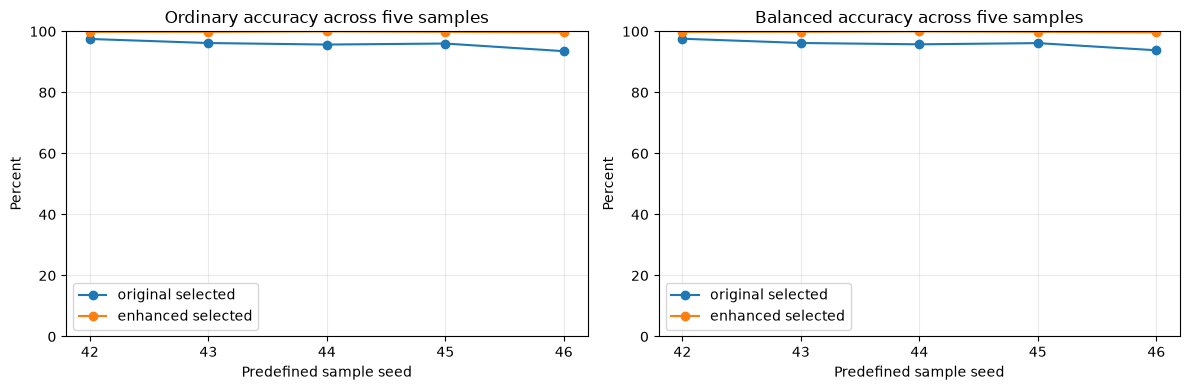
    


    Results saved. Review per-run results and error trade-offs before drawing a conclusion.
    



## 9. Package verified evidence
The manifest excludes itself, avoiding the earlier self-checksum problem. ZIP contents are checked again after creation. Save this executed notebook in Jupyter **before** running this final cell if you want the saved version included. The archive can be reviewed without executing model files.




In [ ]:
# Check completion and package the evidence.

assert finished
assert hashlib.sha256(X.tobytes() + y.tobytes()).hexdigest() == selected_input_digest
stat_now = DATASET_PATH.stat()
assert (stat_now.st_size, stat_now.st_mtime_ns) == (csv_initial_stat.st_size, csv_initial_stat.st_mtime_ns)
save_json("completion_checks.json", {
    "completed_runs": len(results),
    "completed_cv_fits": len(cv_records),
    "completed_full_training_fits": len(results),
    "completed_negative_controls": len(controls),
    "scaler_partitions_verified": len(scaler_checks),
    "saved_prediction_metrics_recomputed": True,
    "inputs_unchanged": True,
    "all_seeds_included": True,
    "protected_history_and_reserve_excluded_by_flow_id": True,
    "final_reserve_scored": False
})
if NOTEBOOK_PATH.is_file():
    (evidence_dir / NOTEBOOK_PATH.name).write_bytes(NOTEBOOK_PATH.read_bytes())
else:
    warnings.warn("Notebook file not found at NOTEBOOK_PATH. Save/send the executed notebook separately.")
manifest = {path.name: sha256_file(path) for path in sorted(evidence_dir.iterdir())
            if path.is_file() and path.name != "manifest_sha256.json"}
save_json("manifest_sha256.json", manifest)
archive_path = OUTPUT_ROOT / f"{run_id}_evidence.zip"
with zipfile.ZipFile(archive_path, "w", compression=zipfile.ZIP_DEFLATED) as archive:
    for path in sorted(evidence_dir.iterdir()):
        if path.is_file():
            archive.write(path, arcname=f"{evidence_dir.name}/{path.name}")
with zipfile.ZipFile(archive_path) as archive:
    assert archive.testzip() is None
    for name, expected in manifest.items():
        assert hashlib.sha256(archive.read(f"{evidence_dir.name}/{name}")).hexdigest() == expected, name
print("Evidence ZIP:", archive_path.resolve())
print("Save the executed notebook again, then send this ZIP for independent evidence review.")


**Recorded output from the supplied run — not rerun here**

    Evidence ZIP: [local folder]/20261004T113920Z_f73df1ba_evidence.zip
    Save the executed notebook again, then send this ZIP for independent evidence review.
    



## Documentation after verification
Do not write “five repeats confirmed improvement” until this notebook has completed and the saved evidence has been checked. Use actual numbers, including adverse runs and variability. Keep training, CV and development-evaluation results distinct. Repeating a deterministic fit with identical data adds reproducibility evidence, not another independently sampled result.

Method references:
- [Scikit-learn cross-validation guide](https://scikit-learn.org/stable/modules/cross_validation.html): grouped splitting and group-aware CV.
- [Scikit-learn common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html): train-only preprocessing and pipelines.
- [StratifiedGroupKFold documentation](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.StratifiedGroupKFold.html): non-overlapping groups and approximate stratification.
- [Wainer & Cawley (2017), JMLR 18(15)](https://jmlr.org/papers/v18/16-174.html): resampling procedures for SVM hyperparameter optimisation. This supports careful evaluation design, not a claim that five repetitions are sufficient in every situation.

JATI writing remains a later phase. This notebook supplies auditable additional development evidence.


